# Beta-Neutral Dynamic Strategy

A **beta-neutral** strategy that dynamically adjusts portfolio weights to maintain
near-zero market beta, using `Weigh.BasedOnBeta`.

The strategy scales an initial allocation so that the portfolio's beta to a reference
asset (AAPL) is approximately zero. High-beta assets get scaled down; low/negative-beta
assets get scaled up.

This notebook demonstrates:
- `Weigh.BasedOnBeta` for beta-targeted allocation
- Dynamic weight adjustment based on rolling beta estimates
- Weight evolution visualisation
- Comparison against static baselines

**Offline mode**: Uses local CSV files — no network required.

In [1]:
from pathlib import Path

import pandas as pd

import tiportfolio as ti

_DATA_DIR = Path("../../tests/data")

CSV_DATA: dict[str, str] = {
    "QQQ": str(_DATA_DIR / "qqq_2018_2024_yf.csv"),
    "BIL": str(_DATA_DIR / "bil_2018_2024_yf.csv"),
    "GLD": str(_DATA_DIR / "gld_2018_2024_yf.csv"),
    "AAPL": str(_DATA_DIR / "aapl_2018_2024_yf.csv"),
}

TICKERS = ["QQQ", "BIL", "GLD"]
INITIAL_RATIO = {"QQQ": 0.7, "BIL": 0.2, "GLD": 0.1}
START = "2019-01-01"
END = "2024-12-31"

## 1. Load Data

AAPL is used as the beta reference (base_data) — not traded in the portfolio.

In [2]:
data = ti.fetch_data(TICKERS, start=START, end=END, csv=CSV_DATA)
aapl_data = ti.fetch_data(["AAPL"], start=START, end=END, csv=CSV_DATA)

for ticker, df in data.items():
    print(f"{ticker}: {df.shape[0]} rows, {df.index[0].date()} \u2192 {df.index[-1].date()}")
print(f"AAPL (reference): {aapl_data['AAPL'].shape[0]} rows")

QQQ: 1760 rows, 2018-01-02 → 2024-12-30
BIL: 1760 rows, 2018-01-02 → 2024-12-30
GLD: 1760 rows, 2018-01-02 → 2024-12-30
AAPL (reference): 1760 rows


## 2. Beta-Neutral Strategy

`Weigh.BasedOnBeta` iteratively scales the initial weights so that the portfolio's
beta to the reference asset approaches the target (0 = market-neutral).

- Uses rolling OLS regression over the lookback window to estimate betas
- Weights are NOT normalised — sum(w) < 1 implies a cash residual
- Monthly rebalancing ensures beta stays near zero as market conditions change

In [3]:
beta_neutral = ti.Portfolio(
    "beta_neutral",
    [
        ti.Signal.Monthly(),
        ti.Select.All(),
        ti.Weigh.BasedOnBeta(
            initial_ratio=INITIAL_RATIO,
            target_beta=0,
            lookback=pd.DateOffset(months=1),
            base_data=aapl_data["AAPL"],
        ),
        ti.Action.Rebalance(),
    ],
    TICKERS,
)

result = ti.run(ti.Backtest(beta_neutral, data))

## 3. Results

In [4]:
result.summary()

,value
sharpe,-0.387
calmar,0.020
sortino,-0.566
max_drawdown,-0.162
cagr,0.003
risk_free_rate,0.040
total_return,0.023
kelly,-4.509
final_value,10226.187
total_fee,27.664


In [5]:
result[0].plot_interactive()

In [6]:
result.full_summary()

,value
sharpe,-0.387
calmar,0.020
sortino,-0.566
max_drawdown,-0.162
cagr,0.003
risk_free_rate,0.040
total_return,0.023
kelly,-4.509
final_value,10226.187
total_fee,27.664


## 4. Weight Evolution

Watch how weights shift over time as the strategy adjusts to maintain zero beta:

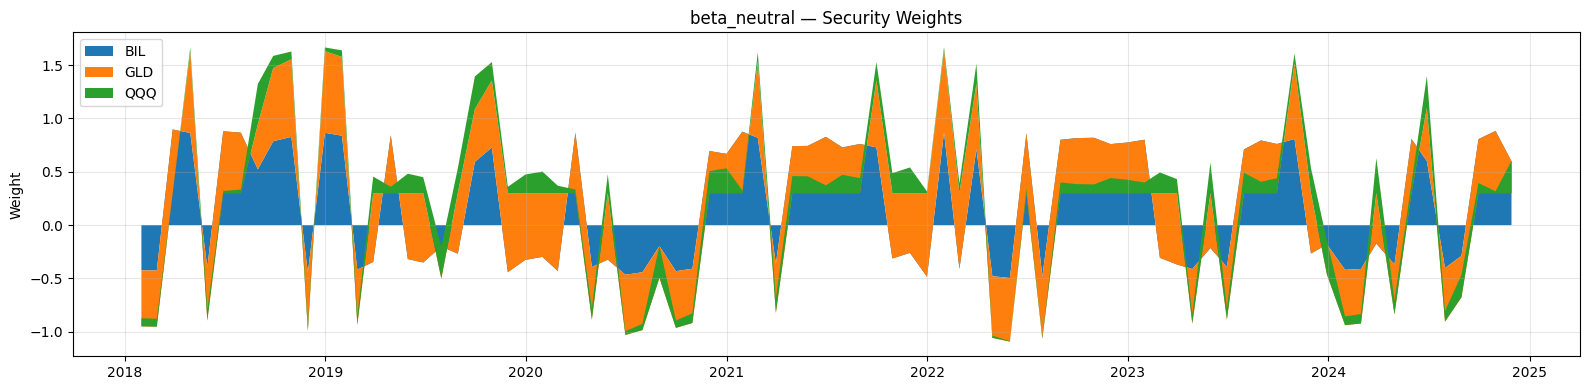

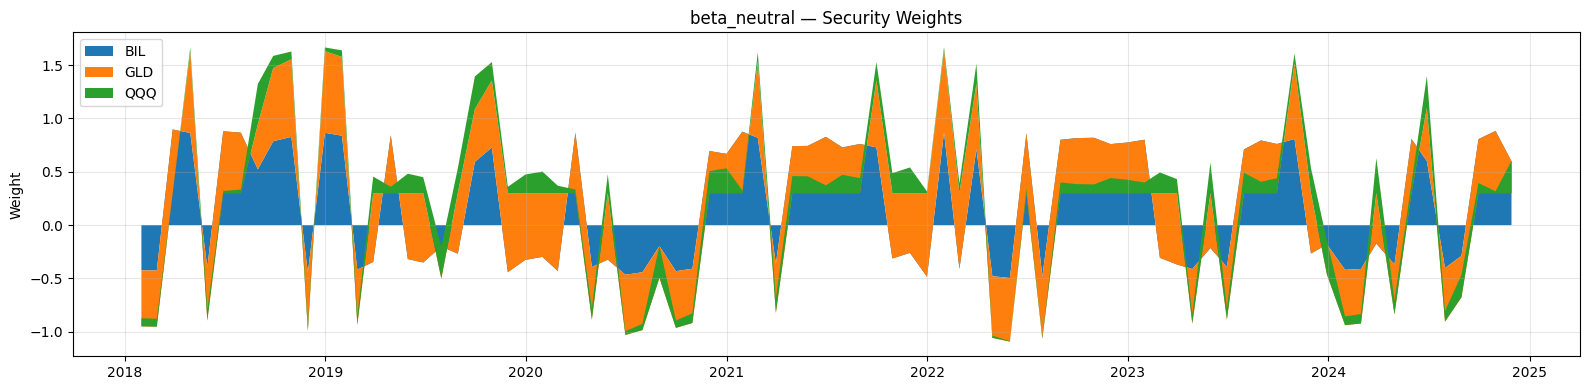

In [7]:
result[0].plot_security_weights()

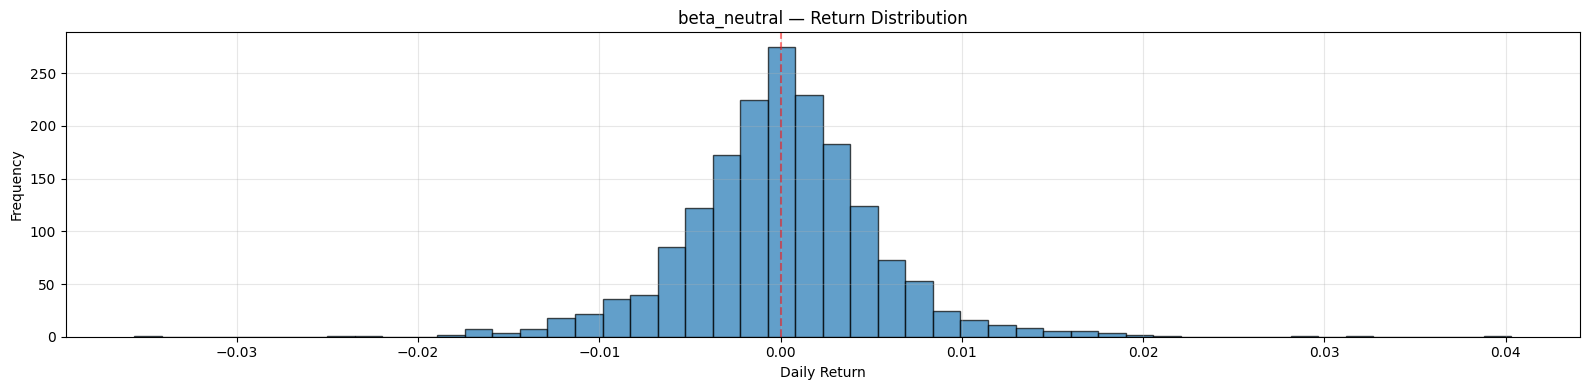

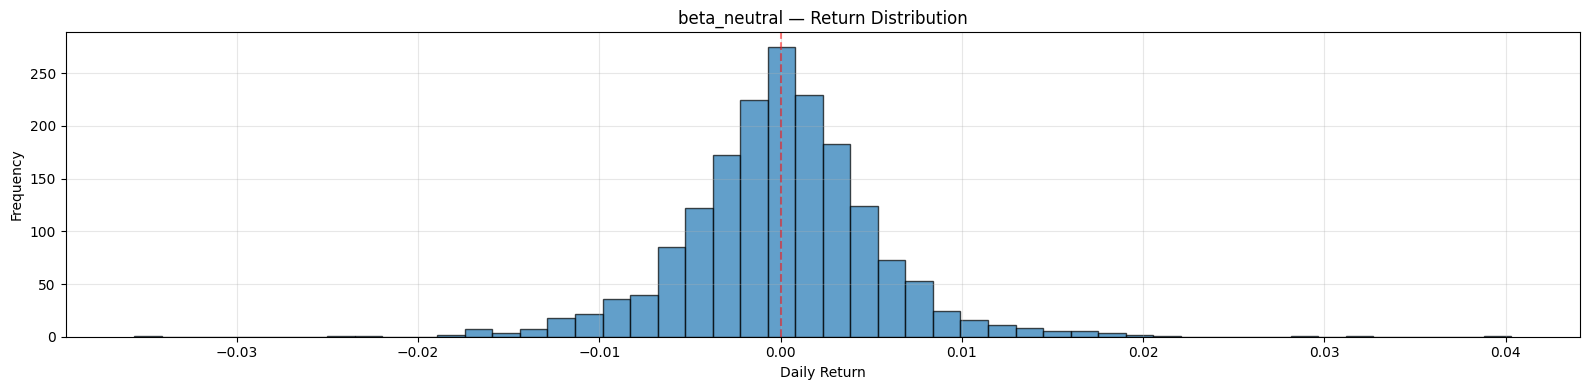

In [8]:
result[0].plot_histogram()

In [9]:
print(f"Total trades: {len(result[0].trades)}")
result[0].trades.sample(5)

Total trades: 249


,date,portfolio,ticker,qty_before,qty_after,delta,price,fee,equity_before,equity_after
0,2018-01-31 05:00:00+00:00,beta_neutral,QQQ,0.000000,4.699028,4.699028,160.765457,0.016447,10000.000000,9999.641555
1,2018-01-31 05:00:00+00:00,beta_neutral,BIL,0.000000,-56.628499,-56.628499,74.954460,0.198200,10000.000000,9999.641555
2,2018-01-31 05:00:00+00:00,beta_neutral,GLD,0.000000,-41.085457,-41.085457,127.650002,0.143799,10000.000000,9999.641555
225,2024-04-30 04:00:00+00:00,beta_neutral,QQQ,7.672090,3.217500,-4.454590,420.507172,0.015591,10295.067199,10294.307780
226,2024-04-30 04:00:00+00:00,beta_neutral,BIL,-21.252095,-44.975074,-23.722979,84.370110,0.083030,10295.067199,10294.307780
33,2018-12-31 05:00:00+00:00,beta_neutral,QQQ,3.446500,2.321891,-1.124609,147.634171,0.003936,9842.919457,9839.032922
34,2018-12-31 05:00:00+00:00,beta_neutral,BIL,-59.951887,111.819933,171.771820,76.156700,0.601201,9842.919457,9839.032922
35,2018-12-31 05:00:00+00:00,beta_neutral,GLD,-48.297602,62.115836,110.413438,121.250000,0.386447,9842.919457,9839.032922
159,2022-06-30 04:00:00+00:00,beta_neutral,QQQ,0.144786,1.451122,1.306335,274.165771,0.004572,10067.197187,10063.555273
160,2022-06-30 04:00:00+00:00,beta_neutral,BIL,-63.855055,111.011663,174.866718,78.033508,0.612034,10067.197187,10063.555273


## 5. Baseline Comparisons

Compare the beta-neutral strategy against:
1. **Equal Weight** — equal allocation across QQQ/BIL/GLD, monthly rebalance
2. **QQQ Only** — 100% QQQ buy-and-hold

In [10]:
equal_weight = ti.Portfolio(
    "equal_weight",
    [ti.Signal.Monthly(), ti.Select.All(), ti.Weigh.Equally(), ti.Action.Rebalance()],
    TICKERS,
)

qqq_only = ti.Portfolio(
    "qqq_only",
    [ti.Signal.Once(), ti.Select.All(), ti.Weigh.Equally(), ti.Action.Rebalance()],
    ["QQQ"],
)

comparison = ti.run(
    ti.Backtest(beta_neutral, data),
    ti.Backtest(equal_weight, data),
    ti.Backtest(qqq_only, data),
)

In [11]:
comparison.summary()

,beta_neutral,equal_weight,qqq_only
sharpe,-0.387,0.655,0.684
calmar,0.020,0.644,0.547
sortino,-0.566,0.875,0.889
max_drawdown,-0.162,-0.162,-0.351
cagr,0.003,0.104,0.192
risk_free_rate,0.040,0.040,0.040
total_return,0.023,0.995,2.411
kelly,-4.509,6.733,2.835
final_value,10226.187,19951.667,34106.625
total_fee,27.664,1.010,0.233


In [12]:
comparison.plot_interactive()

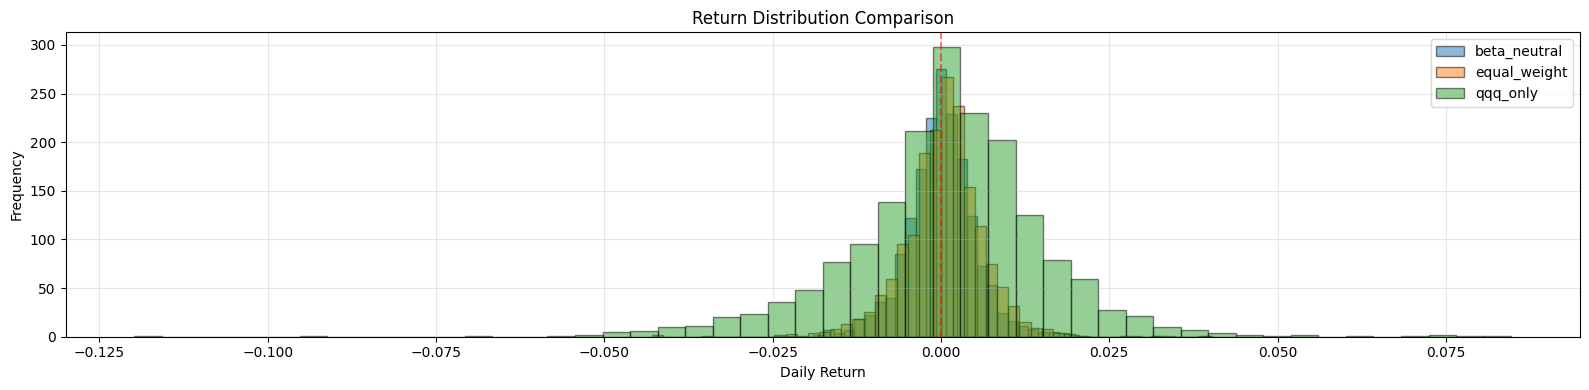

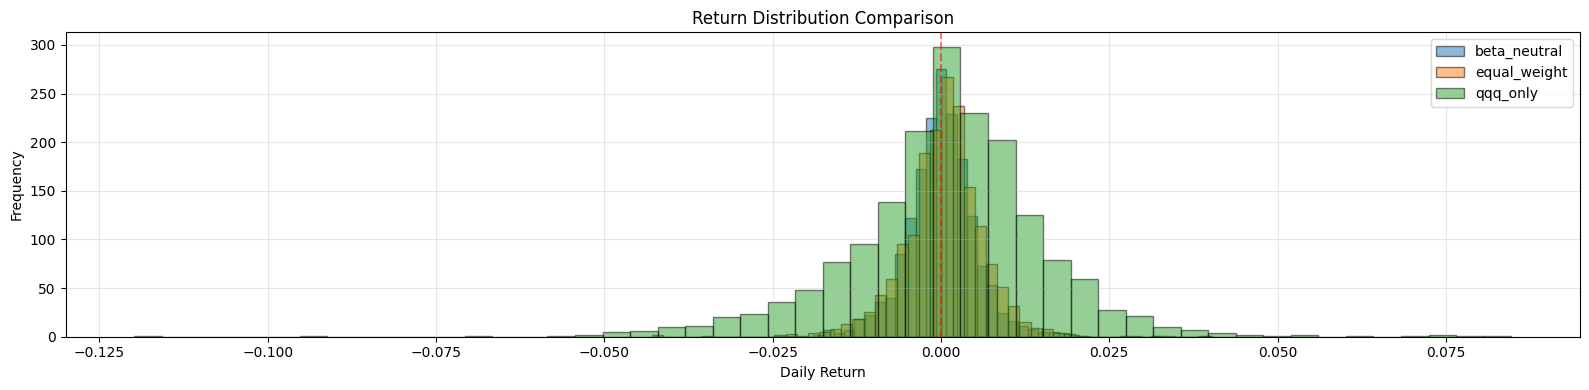

In [13]:
comparison.plot_histogram()